## 1. Импорты, seed и устройство

In [1]:
import os, json, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import sklearn
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"pandas  : {pd.__version__}")
print(f"numpy   : {np.__version__}")
print(f"scikit-learn   : {sklearn.__version__}")
print(f"torch   : {torch.__version__}")
print(f"Device  : {DEVICE}")
print(f"Seed    : {SEED}")

pandas  : 3.0.1
numpy   : 2.4.2
scikit-learn   : 1.8.0
torch   : 2.10.0+cpu
Device  : cpu
Seed    : 42


## 2. Пути и папки

In [2]:
ARTIFACTS_DIR = "./artifacts"
FIGURES_DIR   = "./artifacts/figures"
DATA_PATH     = "./S12-hw-dataset.csv"

for d in [ARTIFACTS_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

print("Directories ready:")

Directories ready:


## 3. Загрузка данных и первичный анализ

### 3.1 Загрузка, преобразование типов и сортировка

In [3]:
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"  Число наблюдений  : {len(df):,}")
print(f"  Диапазон дат      : {df['date'].iloc[0]}  →  {df['date'].iloc[-1]}")
print(f"  Частота           : почасовая (≈180 дней)")
print(f"  Колонки           : {df.columns.tolist()}")
print(f"  Пропуски          : {df.isnull().sum().to_dict()}")
print()
print(df['target'].describe().round(3))

  Число наблюдений  : 4,320
  Диапазон дат      : 2025-01-01 00:00:00  →  2025-06-29 23:00:00
  Частота           : почасовая (≈180 дней)
  Колонки           : ['date', 'target']
  Пропуски          : {'date': 0, 'target': 0}

count    4320.000
mean      135.606
std        21.385
min        69.100
25%       120.538
50%       135.835
75%       150.625
max       210.100
Name: target, dtype: float64


### 3.2 Базовый график временного ряда

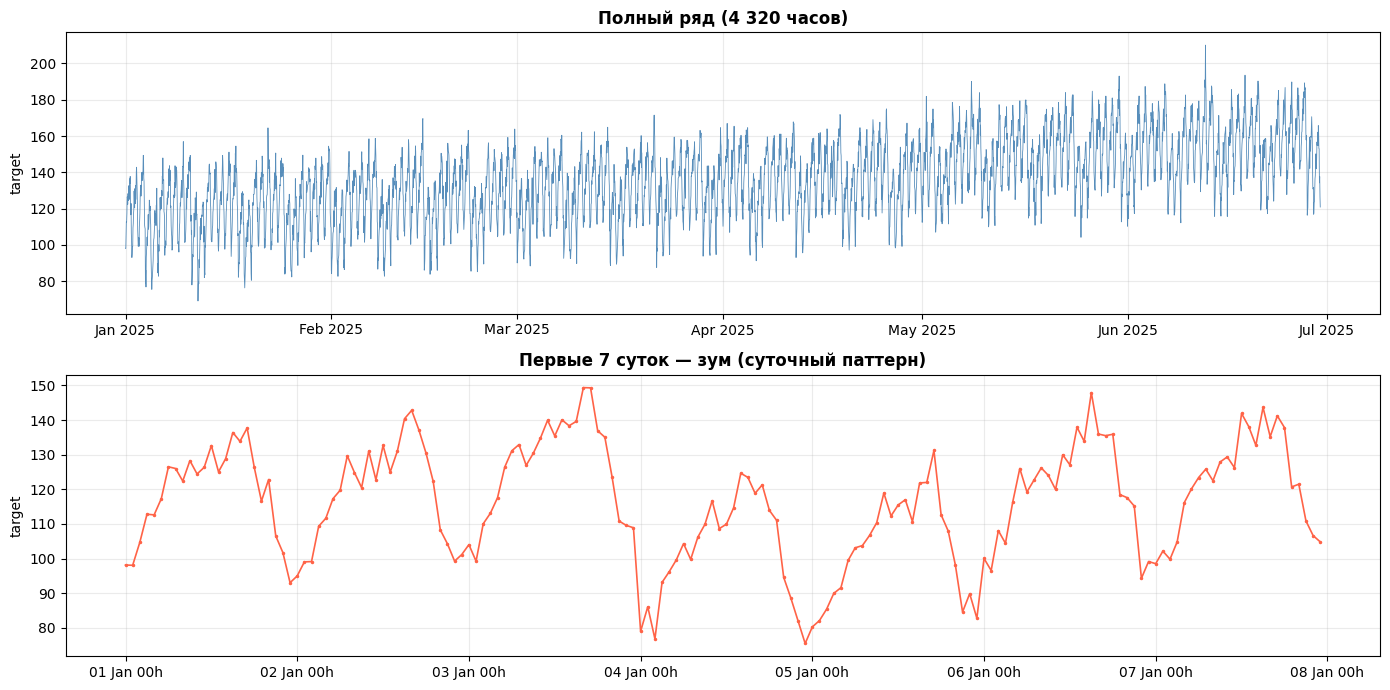


Выражена суточная сезонность (пики/провалы каждые ~24 ч).
Слабо выраженный восходящий тренд на горизонте 6 месяцев.
Отдельные выбросы (значения < 80 и > 200) — возможны аномальные часы.
Пропуски отсутствуют — дополнительная обработка не требуется.


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

# Full series
axes[0].plot(df['date'], df['target'], linewidth=0.6, color='steelblue', alpha=0.9)
axes[0].set_title("Полный ряд (4 320 часов)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("target"); axes[0].grid(alpha=0.25)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# First 7 days (168h) - zoom for daily pattern
axes[1].plot(df['date'].iloc[:168], df['target'].iloc[:168],
             linewidth=1.2, color='tomato', marker='o', markersize=1.5)
axes[1].set_title("Первые 7 суток — зум (суточный паттерн)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("target"); axes[1].grid(alpha=0.25)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Hh'))

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "eda_full_series.png"), dpi=120, bbox_inches='tight')
plt.show()
print("\nВыражена суточная сезонность (пики/провалы каждые ~24 ч).\n"
      "Слабо выраженный восходящий тренд на горизонте 6 месяцев.\n"
      "Отдельные выбросы (значения < 80 и > 200) — возможны аномальные часы.\n"
      "Пропуски отсутствуют — дополнительная обработка не требуется.")

## 4. Корректный temporal split

### 4.1 Разбиение по времени

In [5]:
N = len(df)

TRAIN_END = int(N * 0.70)   # 3024
VAL_END   = int(N * 0.85)   # 3672
# test: [VAL_END : N]       # 648

train_df = df.iloc[:TRAIN_END].copy()
val_df   = df.iloc[TRAIN_END:VAL_END].copy()
test_df  = df.iloc[VAL_END:].copy()

print(f"train : {len(train_df):>5} observations | "
      f"{train_df['date'].iloc[0].date()} → {train_df['date'].iloc[-1].date()}")
print(f"val   : {len(val_df):>5} observations | "
      f"{val_df['date'].iloc[0].date()} → {val_df['date'].iloc[-1].date()}")
print(f"test  : {len(test_df):>5} observations | "
      f"{test_df['date'].iloc[0].date()} → {test_df['date'].iloc[-1].date()}")
print()
print(f"Ratios — train: {len(train_df)/N:.1%}  val: {len(val_df)/N:.1%}  test: {len(test_df)/N:.1%}")

train :  3024 observations | 2025-01-01 → 2025-05-06
val   :   648 observations | 2025-05-07 → 2025-06-02
test  :   648 observations | 2025-06-03 → 2025-06-29

Ratios — train: 70.0%  val: 15.0%  test: 15.0%


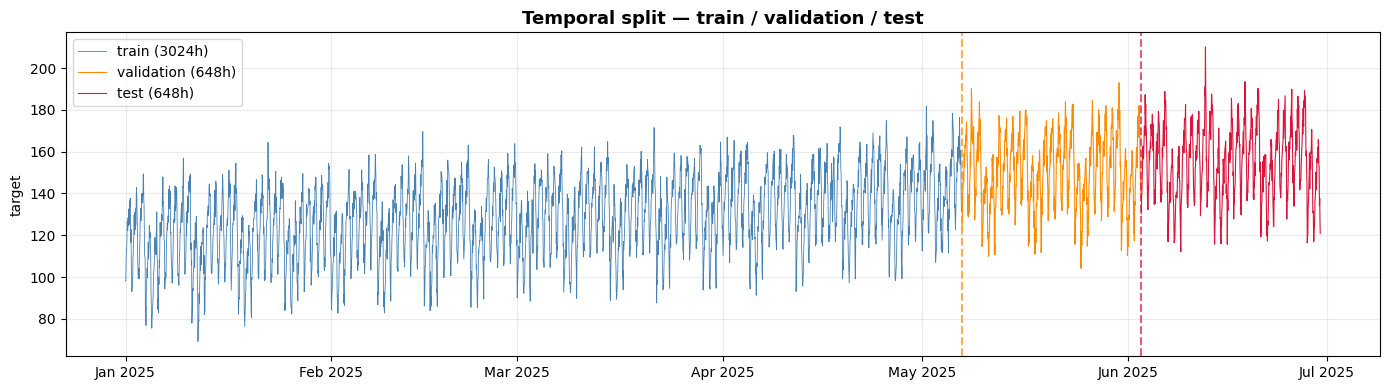

Saved: artifacts/figures/series_split.png


In [6]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train_df['date'], train_df['target'],
        color='steelblue', linewidth=0.6, label=f'train ({len(train_df)}h)')
ax.plot(val_df['date'],   val_df['target'],
        color='darkorange', linewidth=0.8, label=f'validation ({len(val_df)}h)')
ax.plot(test_df['date'],  test_df['target'],
        color='crimson', linewidth=0.8, label=f'test ({len(test_df)}h)')

ax.axvline(x=val_df['date'].iloc[0],  color='darkorange', linestyle='--', linewidth=1.5, alpha=0.7)
ax.axvline(x=test_df['date'].iloc[0], color='crimson',    linestyle='--', linewidth=1.5, alpha=0.7)

ax.set_title("Temporal split — train / validation / test", fontsize=13, fontweight='bold')
ax.set_ylabel("target"); ax.legend(fontsize=10); ax.grid(alpha=0.25)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "series_split.png"), dpi=120, bbox_inches='tight')
plt.show()
print("Saved: artifacts/figures/series_split.png")

**Почему random split здесь некорректен:** при случайном перемешивании модель видит «будущие»
значения ряда во время обучения, что создаёт утечку данных. Метрики на таком split окажутся
завышены, а реальная прогностическая способность модели не будет проверена.

In [7]:
print("Temporal split вместо random split:")
print(f"  train : строки 0..{TRAIN_END-1}  ({train_df['date'].iloc[0].date()} — {train_df['date'].iloc[-1].date()})")
print(f"  val   : строки {TRAIN_END}..{VAL_END-1}  ({val_df['date'].iloc[0].date()} — {val_df['date'].iloc[-1].date()})")
print(f"  test  : строки {VAL_END}..{N-1}  ({test_df['date'].iloc[0].date()} — {test_df['date'].iloc[-1].date()})")
print()
print("random split некорректен, потому что:")
print("  - создаёт утечку данных из будущего в обучение;")
print("  - лаговые/rolling признаки теряют временной смысл;")
print("  - метрики становятся нереалистично оптимистичными.")


Temporal split вместо random split:
  train : строки 0..3023  (2025-01-01 — 2025-05-06)
  val   : строки 3024..3671  (2025-05-07 — 2025-06-02)
  test  : строки 3672..4319  (2025-06-03 — 2025-06-29)

random split некорректен, потому что:
  - создаёт утечку данных из будущего в обучение;
  - лаговые/rolling признаки теряют временной смысл;
  - метрики становятся нереалистично оптимистичными.


## 5. Признаки для baseline-моделей (B3)

In [8]:
def add_features(df_: pd.DataFrame) -> pd.DataFrame:
    """Add lag / rolling / calendar features to a copy of df_.
    No future leakage: all features are computed on the chronologically ordered series.
    """
    d = df_.copy().sort_values('date').reset_index(drop=True)

    d['lag_1']   = d['target'].shift(1)    # 1 час назад
    d['lag_7']   = d['target'].shift(7)    # 7 часов назад
    d['lag_14']  = d['target'].shift(14)   # 14 часов назад
    d['lag_24']  = d['target'].shift(24)   # вчерашний час (24 ч)
    d['lag_168'] = d['target'].shift(168)  # тот же час прошлой недели

    # Rolling features (shift(1) ПЕРЕД rolling исключает текущее значение)
    d['rolling_mean_7']  = d['target'].shift(1).rolling(7,  min_periods=1).mean()
    d['rolling_std_7']   = d['target'].shift(1).rolling(7,  min_periods=1).std().fillna(0)
    d['rolling_mean_24'] = d['target'].shift(1).rolling(24, min_periods=1).mean()

    # Calendar features
    d['hour']       = d['date'].dt.hour
    d['dayofweek']  = d['date'].dt.dayofweek
    d['is_weekend'] = (d['dayofweek'] >= 5).astype(int)

    return d


df_feat = add_features(df)

train_f = df_feat.iloc[:TRAIN_END].copy()
val_f   = df_feat.iloc[TRAIN_END:VAL_END].copy()
test_f  = df_feat.iloc[VAL_END:].copy()

FEATURE_COLS = ['lag_1','lag_7','lag_14','lag_24','lag_168',
                'rolling_mean_7','rolling_std_7','rolling_mean_24',
                'hour','dayofweek','is_weekend']

train_f_clean = train_f[FEATURE_COLS + ['target']].dropna()
val_f_clean   = val_f[FEATURE_COLS + ['target']].dropna()
test_f_clean  = test_f[FEATURE_COLS + ['target']].dropna()

print("Feature sets (after dropna):")
print(f"  train : {len(train_f_clean):>4} rows  (dropped {len(train_f)-len(train_f_clean)} NaN-head rows)")
print(f"  val   : {len(val_f_clean):>4} rows")
print(f"  test  : {len(test_f_clean):>4} rows")
print(f"  Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")


Feature sets (after dropna):
  train : 2856 rows  (dropped 168 NaN-head rows)
  val   :  648 rows
  test  :  648 rows
  Features (11): ['lag_1', 'lag_7', 'lag_14', 'lag_24', 'lag_168', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_24', 'hour', 'dayofweek', 'is_weekend']


In [9]:
# ── StandardScaler fitted ONLY on train ──────────────────────────
feat_scaler = StandardScaler()
X_train_sc  = feat_scaler.fit_transform(train_f_clean[FEATURE_COLS])
X_val_sc    = feat_scaler.transform(val_f_clean[FEATURE_COLS])
X_test_sc   = feat_scaler.transform(test_f_clean[FEATURE_COLS])

y_train = train_f_clean['target'].values
y_val   = val_f_clean['target'].values
y_test  = test_f_clean['target'].values

print(f"X_train_sc : {X_train_sc.shape}")
print(f"X_val_sc   : {X_val_sc.shape}")
print(f"X_test_sc  : {X_test_sc.shape}")
print("Scaler fitted on train only — no leakage.")

X_train_sc : (2856, 11)
X_val_sc   : (648, 11)
X_test_sc  : (648, 11)
Scaler fitted on train only — no leakage.


## 6. Вспомогательная функция метрик

In [10]:
def calc_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """Return MAE, RMSE, MAPE (%) for a forecast."""
    mae  = float(mean_absolute_error(y_true, y_pred))
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mask = y_true != 0
    mape = float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)
    return dict(mae=round(mae, 5), rmse=round(rmse, 5), mape=round(mape, 5))


def print_metrics(label: str, metrics: dict):
    print(f"  [{label}]  MAE={metrics['mae']:.4f}  "
          f"RMSE={metrics['rmse']:.4f}  MAPE={metrics['mape']:.2f}%")


print("calc_metrics() ready.")

calc_metrics() ready.


## 7. Эксперименты

### B1 — naive-last

Прогноз равен последнему известному значению: y_t = y_{t-1}.

In [11]:
print("=" * 55)
print("B1: naive-last")
print("=" * 55)

y_val_pred_b1  = val_f_clean['lag_1'].values
y_test_pred_b1 = test_f_clean['lag_1'].values

m_b1_val  = calc_metrics(y_val,  y_val_pred_b1)
m_b1_test = calc_metrics(y_test, y_test_pred_b1)
print_metrics("B1 val",  m_b1_val)
print_metrics("B1 test", m_b1_test)

B1: naive-last
  [B1 val]  MAE=6.4448  RMSE=8.2010  MAPE=4.40%
  [B1 test]  MAE=6.3424  RMSE=8.0591  MAPE=4.15%


### B2 — moving-average (w=24)

In [12]:
print("=" * 55)
print("B2: moving-average (window=24h)")
print("=" * 55)

y_val_pred_b2  = val_f_clean['rolling_mean_24'].values
y_test_pred_b2 = test_f_clean['rolling_mean_24'].values

m_b2_val  = calc_metrics(y_val,  y_val_pred_b2)
m_b2_test = calc_metrics(y_test, y_test_pred_b2)
print_metrics("B2 val",  m_b2_val)
print_metrics("B2 test", m_b2_test)

B2: moving-average (window=24h)
  [B2 val]  MAE=13.3980  RMSE=16.1699  MAPE=9.20%
  [B2 test]  MAE=13.1405  RMSE=16.1108  MAPE=8.74%


### B3 — Ridge на лаговых/rolling/календарных признаках

In [13]:
print("=" * 55)
print("B3: Ridge(alpha=1.0) on lag/rolling/calendar features")
print("=" * 55)

ridge = Ridge(alpha=1.0, random_state=SEED)
ridge.fit(X_train_sc, y_train)

y_val_pred_b3  = ridge.predict(X_val_sc)
y_test_pred_b3 = ridge.predict(X_test_sc)

m_b3_val  = calc_metrics(y_val,  y_val_pred_b3)
m_b3_test = calc_metrics(y_test, y_test_pred_b3)
print_metrics("B3 val",  m_b3_val)
print_metrics("B3 test", m_b3_test)

# Feature importances (coefficients)
coef_df = pd.DataFrame({'feature': FEATURE_COLS,
                         'coef': ridge.coef_}).sort_values('coef', key=abs, ascending=False)
print()
print("Top-5 features by |coef|:")
print(coef_df.head().to_string(index=False))

B3: Ridge(alpha=1.0) on lag/rolling/calendar features
  [B3 val]  MAE=4.8571  RMSE=6.2004  MAPE=3.25%
  [B3 test]  MAE=4.5270  RMSE=5.8255  MAPE=2.91%

Top-5 features by |coef|:
        feature      coef
        lag_168  7.853133
          lag_1  7.011025
rolling_mean_24  1.916433
         lag_14 -1.540524
          lag_7 -1.365288


### R1 — GRU на оконном представлении

#### R1.1 Подготовка данных для GRU (window_size=24)

In [14]:
WINDOW_SIZE = 24   # 24 часа = 1 сутки lookback
HORIZON     = 1    # прогноз на 1 шаг вперёд

# Scale target with MinMax on train
from sklearn.preprocessing import MinMaxScaler

target_scaler = MinMaxScaler()
target_scaler.fit(train_df[['target']])

full_target_scaled = target_scaler.transform(df[['target']]).flatten()

# Split scaled series
train_scaled = full_target_scaled[:TRAIN_END]
val_scaled   = full_target_scaled[TRAIN_END:VAL_END]
test_scaled  = full_target_scaled[VAL_END:]

print(f"Window size : {WINDOW_SIZE} h")
print(f"Horizon     : {HORIZON} h (one-step-ahead)")
print(f"Target scaler fitted on train only.")
print(f"Scaled range check — train: [{train_scaled.min():.3f}, {train_scaled.max():.3f}]")


class TimeSeriesDataset(Dataset):
    """Sliding-window dataset for time series one-step forecasting."""

    def __init__(self, series: np.ndarray, window: int, horizon: int = 1):
        self.series  = series.astype(np.float32)
        self.window  = window
        self.horizon = horizon
        self.n       = len(series) - window - horizon + 1

    def __len__(self):
        return max(self.n, 0)

    def __getitem__(self, idx):
        x = self.series[idx : idx + self.window]
        y = self.series[idx + self.window + self.horizon - 1]
        return torch.tensor(x).unsqueeze(-1), torch.tensor(y)   # (W,1), scalar


val_series  = full_target_scaled[TRAIN_END - WINDOW_SIZE : VAL_END]
test_series = full_target_scaled[VAL_END  - WINDOW_SIZE : ]

ds_train = TimeSeriesDataset(train_scaled,  WINDOW_SIZE, HORIZON)
ds_val   = TimeSeriesDataset(val_series,    WINDOW_SIZE, HORIZON)
ds_test  = TimeSeriesDataset(test_series,   WINDOW_SIZE, HORIZON)

BATCH_SIZE = 64
dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
dl_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False)
dl_test  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False)

print(f"\nDataset sizes  — train: {len(ds_train)} | val: {len(ds_val)} | test: {len(ds_test)}")
print(f"Batches/epoch  — train: {len(dl_train)} | val: {len(dl_val)}")

# Quick shape sanity-check
x0, y0 = next(iter(dl_train))
print(f"\nBatch shapes: x={tuple(x0.shape)}, y={tuple(y0.shape)}")

Window size : 24 h
Horizon     : 1 h (one-step-ahead)
Target scaler fitted on train only.
Scaled range check — train: [0.000, 1.000]

Dataset sizes  — train: 3000 | val: 648 | test: 648
Batches/epoch  — train: 47 | val: 11

Batch shapes: x=(64, 24, 1), y=(64,)


#### R1.2 Архитектура GRU

In [15]:
class GRUForecaster(nn.Module):
    """Single-layer GRU for one-step forecasting.

    Input  : (batch, seq_len, input_size=1)
    Output : (batch,)  — predicted next value (scaled)
    """

    def __init__(self, input_size: int = 1, hidden_size: int = 64,
                 num_layers: int = 1, dropout: float = 0.0):
        super().__init__()
        self.gru = nn.GRU(input_size=input_size,
                          hidden_size=hidden_size,
                          num_layers=num_layers,
                          batch_first=True,
                          dropout=dropout if num_layers > 1 else 0.0)
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, W, 1)
        out, _ = self.gru(x)          # out: (B, W, H)
        last   = out[:, -1, :]        # (B, H) — last time step
        return self.head(last).squeeze(-1)   # (B,)


HIDDEN_SIZE = 64

_model_test = GRUForecaster(hidden_size=HIDDEN_SIZE)
_x_test     = torch.zeros(2, WINDOW_SIZE, 1)
assert _model_test(_x_test).shape == (2,)

n_params = sum(p.numel() for p in _model_test.parameters())
print(f"GRUForecaster  hidden={HIDDEN_SIZE}  params={n_params:,}")
del _model_test, _x_test

GRUForecaster  hidden=64  params=14,977


#### R1.3 Цикл обучения GRU

In [16]:
def train_epoch_gru(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, n = 0.0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(y)
        n += len(y)
    return total_loss / n


@torch.no_grad()
def eval_epoch_gru(model, loader, criterion, device):
    model.eval()
    total_loss, n = 0.0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = model(x)
        loss = criterion(pred, y)
        total_loss += loss.item() * len(y)
        n += len(y)
    return total_loss / n


@torch.no_grad()
def predict_gru(model, loader, device, scaler):
    """Run inference and inverse-transform predictions back to original scale."""
    model.eval()
    preds = []
    for x, _ in loader:
        x    = x.to(device)
        pred = model(x).cpu().numpy()
        preds.append(pred)
    preds_scaled = np.concatenate(preds)
    preds_orig   = scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
    return preds_orig


print("GRU training utilities ready.")

GRU training utilities ready.


#### R1.4 Обучение GRU

In [17]:
MAX_EPOCHS = 30
LR_GRU     = 1e-3
PATIENCE   = 7

print("=" * 55)
print(f"R1: GRU  hidden={HIDDEN_SIZE}  window={WINDOW_SIZE}  lr={LR_GRU}")
print("=" * 55)

gru_model = GRUForecaster(hidden_size=HIDDEN_SIZE).to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(gru_model.parameters(), lr=LR_GRU, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=4
)

history_gru    = {'train_loss': [], 'val_loss': []}
best_val_loss  = float('inf')
best_state_gru = None
epochs_no_imp  = 0

for epoch in range(1, MAX_EPOCHS + 1):
    tr_loss = train_epoch_gru(gru_model, dl_train, criterion, optimizer, DEVICE)
    vl_loss = eval_epoch_gru(gru_model, dl_val,   criterion, DEVICE)
    scheduler.step(vl_loss)

    history_gru['train_loss'].append(tr_loss)
    history_gru['val_loss'].append(vl_loss)

    if vl_loss < best_val_loss:
        best_val_loss  = vl_loss
        best_state_gru = {k: v.cpu().clone() for k, v in gru_model.state_dict().items()}
        epochs_no_imp  = 0
        marker = " ← best"
    else:
        epochs_no_imp += 1
        marker = ""

    if epoch == 1 or epoch % 5 == 0 or marker:
        print(f"  epoch {epoch:>3}/{MAX_EPOCHS} | "
              f"train_loss={tr_loss:.6f}  val_loss={vl_loss:.6f}{marker}")

    if epochs_no_imp >= PATIENCE:
        print(f"  Early stopping at epoch {epoch}")
        break

gru_model.load_state_dict(best_state_gru)
print(f"\nBest val MSE (scaled): {best_val_loss:.6f}")
EPOCHS_TRAINED = epoch

R1: GRU  hidden=64  window=24  lr=0.001
  epoch   1/30 | train_loss=0.087995  val_loss=0.024312 ← best
  epoch   2/30 | train_loss=0.021143  val_loss=0.022095 ← best
  epoch   3/30 | train_loss=0.017648  val_loss=0.018130 ← best
  epoch   4/30 | train_loss=0.015268  val_loss=0.013979 ← best
  epoch   5/30 | train_loss=0.012682  val_loss=0.009985 ← best
  epoch   6/30 | train_loss=0.009954  val_loss=0.007231 ← best
  epoch   7/30 | train_loss=0.007293  val_loss=0.006501 ← best
  epoch   8/30 | train_loss=0.005519  val_loss=0.005683 ← best
  epoch   9/30 | train_loss=0.005108  val_loss=0.005324 ← best
  epoch  10/30 | train_loss=0.004826  val_loss=0.005058 ← best
  epoch  11/30 | train_loss=0.004671  val_loss=0.004836 ← best
  epoch  12/30 | train_loss=0.004594  val_loss=0.004816 ← best
  epoch  13/30 | train_loss=0.004511  val_loss=0.004737 ← best
  epoch  14/30 | train_loss=0.004458  val_loss=0.004671 ← best
  epoch  15/30 | train_loss=0.004402  val_loss=0.004600 ← best
  epoch  16/30 

#### R1.5 Предсказания GRU на val и test

In [18]:
# val predictions
def collect_targets(loader, scaler):
    ys = []
    for _, y in loader:
        ys.append(y.numpy())
    ys_scaled = np.concatenate(ys)
    return scaler.inverse_transform(ys_scaled.reshape(-1, 1)).flatten()

y_val_true_gru  = collect_targets(dl_val,  target_scaler)
y_test_true_gru = collect_targets(dl_test, target_scaler)

y_val_pred_r1  = predict_gru(gru_model, dl_val,  DEVICE, target_scaler)
y_test_pred_r1 = predict_gru(gru_model, dl_test, DEVICE, target_scaler)

m_r1_val  = calc_metrics(y_val_true_gru,  y_val_pred_r1)
m_r1_test = calc_metrics(y_test_true_gru, y_test_pred_r1)
print_metrics("R1 val",  m_r1_val)
print_metrics("R1 test", m_r1_test)

  [R1 val]  MAE=5.8148  RMSE=7.3415  MAPE=3.91%
  [R1 test]  MAE=6.0276  RMSE=7.6901  MAPE=3.90%


#### R1.6 Кривые обучения GRU

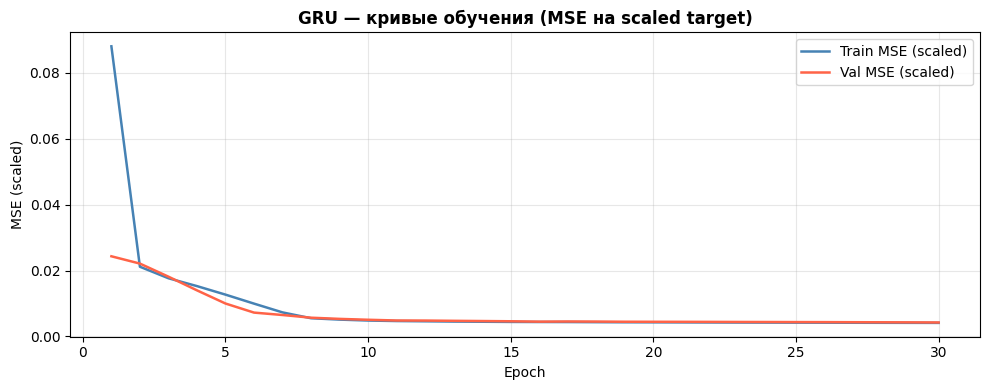

Saved: artifacts/figures/gru_learning_curves.png


In [19]:
ep_range = range(1, len(history_gru['train_loss']) + 1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ep_range, history_gru['train_loss'], label='Train MSE (scaled)', color='steelblue', linewidth=1.8)
ax.plot(ep_range, history_gru['val_loss'],   label='Val MSE (scaled)',   color='tomato',    linewidth=1.8)
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (scaled)')
ax.set_title('GRU — кривые обучения (MSE на scaled target)', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "gru_learning_curves.png"), dpi=120, bbox_inches='tight')
plt.show()
print("Saved: artifacts/figures/gru_learning_curves.png")

## 8. Сравнение B1-B3 и R1 на validation

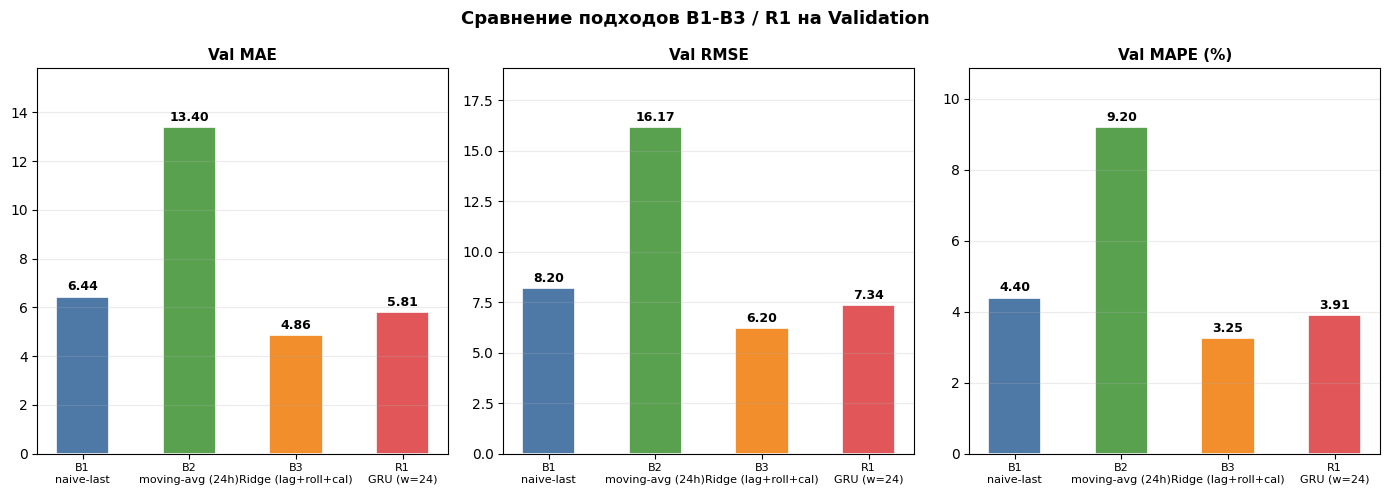

Saved: artifacts/figures/baselines_compare.png

  B1  naive-last                  val_MAE = 6.4448
  B2  moving-avg (24h)            val_MAE = 13.3980
  B3  Ridge (lag+roll+cal)        val_MAE = 4.8571 ← BEST (val MAE)
  R1  GRU (w=24)                  val_MAE = 5.8148


In [20]:
model_ids  = ['B1', 'B2', 'B3', 'R1']
model_labels = ['naive-last', 'moving-avg (24h)', 'Ridge (lag+roll+cal)', 'GRU (w=24)']
val_maes  = [m_b1_val['mae'], m_b2_val['mae'], m_b3_val['mae'], m_r1_val['mae']]
val_rmses = [m_b1_val['rmse'], m_b2_val['rmse'], m_b3_val['rmse'], m_r1_val['rmse']]
val_mapes = [m_b1_val['mape'], m_b2_val['mape'], m_b3_val['mape'], m_r1_val['mape']]
colors_bar = ['#4e79a7', '#59a14f', '#f28e2b', '#e15759']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metric_sets = [(val_maes, 'Val MAE'), (val_rmses, 'Val RMSE'), (val_mapes, 'Val MAPE (%)')]

for ax, (vals, label) in zip(axes, metric_sets):
    bars = ax.bar(model_ids, vals, color=colors_bar, width=0.5, edgecolor='white', linewidth=1.2)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                f"{v:.2f}", ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_xticklabels([f"{mid}\n{ml}" for mid, ml in zip(model_ids, model_labels)], fontsize=8)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylim(0, max(vals) * 1.18)
    ax.grid(True, axis='y', alpha=0.25)

plt.suptitle("Сравнение подходов B1-B3 / R1 на Validation", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "baselines_compare.png"), dpi=120, bbox_inches='tight')
plt.show()
print("Saved: artifacts/figures/baselines_compare.png")
print()
for mid, ml, mae in zip(model_ids, model_labels, val_maes):
    marker = " ← BEST (val MAE)" if mae == min(val_maes) else ""
    print(f"  {mid:>2}  {ml:<26}  val_MAE = {mae:.4f}{marker}")

## 9. Выбор лучшей модели и финальная оценка на test (ОДИН РАЗ)

In [21]:
# Select best by val_MAE
all_val_maes = {'B1': m_b1_val['mae'], 'B2': m_b2_val['mae'],
                'B3': m_b3_val['mae'], 'R1': m_r1_val['mae']}
best_id = min(all_val_maes, key=all_val_maes.get)
print(f"Best model by val_MAE: {best_id}  (val_MAE = {all_val_maes[best_id]:.4f})")

# Retrieve test metrics for best model
best_test_metrics_map = {
    'B1': m_b1_test, 'B2': m_b2_test, 'B3': m_b3_test, 'R1': m_r1_test
}
best_test_metrics = best_test_metrics_map[best_id]

print()
print("=" * 55)
print(f"FINAL TEST RESULT  —  {best_id}")
print(f"  test_MAE  = {best_test_metrics['mae']:.4f}")
print(f"  test_RMSE = {best_test_metrics['rmse']:.4f}")
print(f"  test_MAPE = {best_test_metrics['mape']:.2f}%")
print("=" * 55)

Best model by val_MAE: B3  (val_MAE = 4.8571)

FINAL TEST RESULT  —  B3
  test_MAE  = 4.5270
  test_RMSE = 5.8255
  test_MAPE = 2.91%


### 9.1 Визуализация прогноза лучшей модели на test

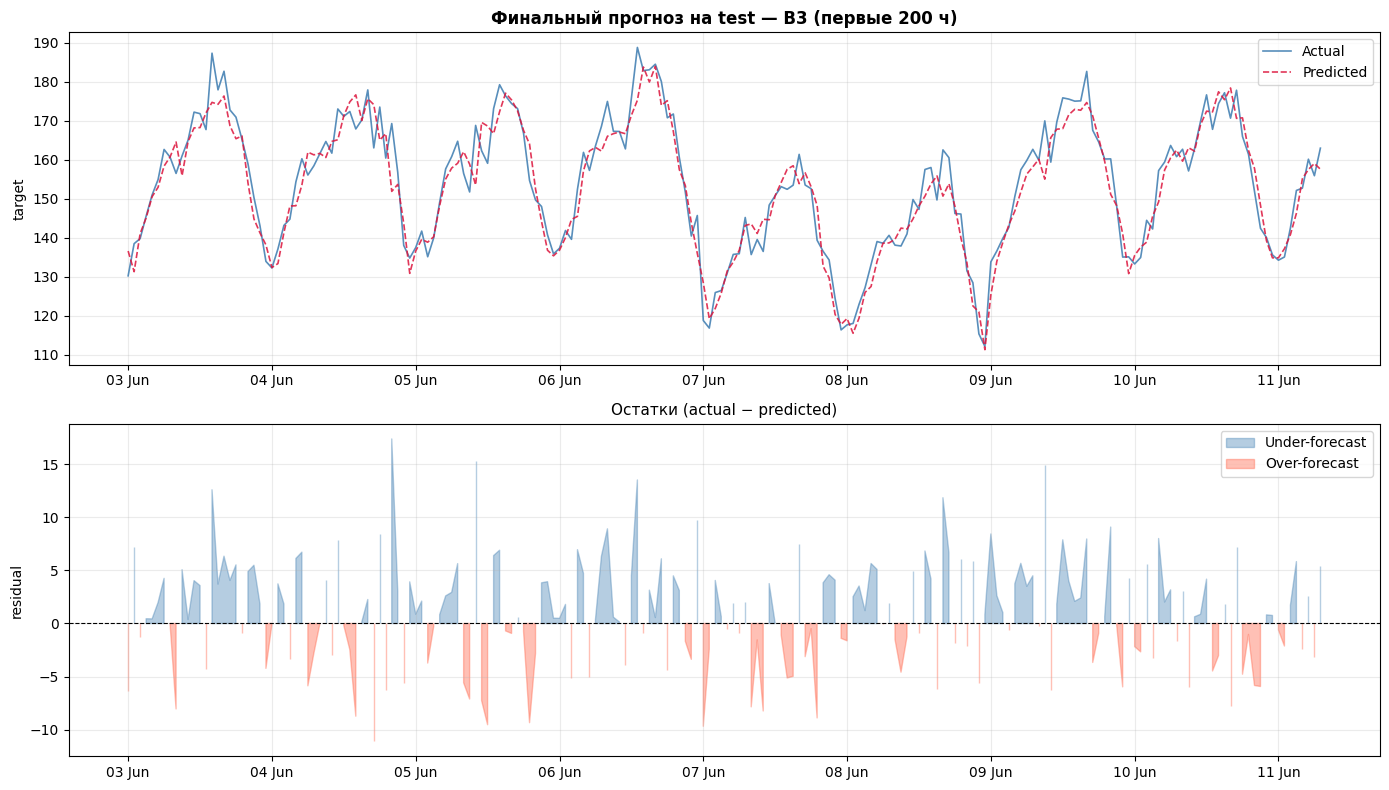

Saved: artifacts/figures/best_forecast_test.png


In [22]:
PLOT_N = 200

test_dates_feat = test_f.iloc[:len(test_f_clean)]['date'].values

test_dates_gru  = df['date'].values[VAL_END + WINDOW_SIZE :][:len(y_test_true_gru)]

if best_id == 'R1':
    y_true_plot  = y_test_true_gru[:PLOT_N]
    y_pred_plot  = y_test_pred_r1[:PLOT_N]
    dates_plot   = test_dates_gru[:PLOT_N]
elif best_id == 'B1':
    y_true_plot  = y_test[:PLOT_N]
    y_pred_plot  = y_test_pred_b1[:PLOT_N]
    dates_plot   = test_dates_feat[:PLOT_N]
elif best_id == 'B2':
    y_true_plot  = y_test[:PLOT_N]
    y_pred_plot  = y_test_pred_b2[:PLOT_N]
    dates_plot   = test_dates_feat[:PLOT_N]
else:  # B3
    y_true_plot  = y_test[:PLOT_N]
    y_pred_plot  = y_test_pred_b3[:PLOT_N]
    dates_plot   = test_dates_feat[:PLOT_N]

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(dates_plot, y_true_plot,  color='steelblue',  linewidth=1.2, label='Actual',    alpha=0.9)
axes[0].plot(dates_plot, y_pred_plot,  color='crimson',    linewidth=1.2, label='Predicted', alpha=0.85, linestyle='--')
axes[0].set_title(f"Финальный прогноз на test — {best_id} (первые {PLOT_N} ч)",
                   fontsize=12, fontweight='bold')
axes[0].set_ylabel("target"); axes[0].legend(); axes[0].grid(alpha=0.25)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

residuals = y_true_plot - y_pred_plot
axes[1].fill_between(dates_plot, residuals, 0, where=residuals >= 0,
                     color='steelblue', alpha=0.4, label='Under-forecast')
axes[1].fill_between(dates_plot, residuals, 0, where=residuals < 0,
                     color='tomato',   alpha=0.4, label='Over-forecast')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title("Остатки (actual − predicted)", fontsize=11)
axes[1].set_ylabel("residual"); axes[1].legend(); axes[1].grid(alpha=0.25)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "best_forecast_test.png"), dpi=120, bbox_inches='tight')
plt.show()
print("Saved: artifacts/figures/best_forecast_test.png")

## 10. Артефакты — runs.csv

In [23]:
SPLIT_SUMMARY = f"train=0:{TRAIN_END} / val={TRAIN_END}:{VAL_END} / test={VAL_END}:{N}"
DATASET_NAME  = "S12-hw-dataset.csv"

def _test_metric(exp_id: str, key: str, metric_dict: dict):
    return metric_dict[key] if exp_id == best_id else ''

rows = [
    dict(
        experiment_id='B1', task='forecasting',
        dataset=DATASET_NAME, seed=SEED,
        split_summary=SPLIT_SUMMARY,
        window_size='N/A', horizon=HORIZON,
        model_summary='naive-last: y_t = y_{t-1}',
        features_summary='lag_1',
        scaler='None', optimizer='None', lr='',
        epochs_trained=0,
        best_val_mae=m_b1_val['mae'], best_val_rmse=m_b1_val['rmse'], best_val_mape=m_b1_val['mape'],
        test_mae  =_test_metric('B1', 'mae',  m_b1_test),
        test_rmse =_test_metric('B1', 'rmse', m_b1_test),
        test_mape =_test_metric('B1', 'mape', m_b1_test),
        notes='Naive baseline. No training. Test filled only if best by val_MAE.',
    ),
    dict(
        experiment_id='B2', task='forecasting',
        dataset=DATASET_NAME, seed=SEED,
        split_summary=SPLIT_SUMMARY,
        window_size=24, horizon=HORIZON,
        model_summary='moving-average window=24h',
        features_summary='rolling_mean_24 (shift 1, no leakage)',
        scaler='None', optimizer='None', lr='',
        epochs_trained=0,
        best_val_mae=m_b2_val['mae'], best_val_rmse=m_b2_val['rmse'], best_val_mape=m_b2_val['mape'],
        test_mae  =_test_metric('B2', 'mae',  m_b2_test),
        test_rmse =_test_metric('B2', 'rmse', m_b2_test),
        test_mape =_test_metric('B2', 'mape', m_b2_test),
        notes='Rolling mean over 24h window. No training. Test filled only if best.',
    ),
    dict(
        experiment_id='B3', task='forecasting',
        dataset=DATASET_NAME, seed=SEED,
        split_summary=SPLIT_SUMMARY,
        window_size='N/A', horizon=HORIZON,
        model_summary='Ridge(alpha=1.0)',
        features_summary='lag_1/7/14/24/168, rolling_mean_7/24, rolling_std_7, hour, dayofweek, is_weekend',
        scaler='StandardScaler (fit on train only)', optimizer='analytical (sklearn)', lr='',
        epochs_trained=0,
        best_val_mae=m_b3_val['mae'], best_val_rmse=m_b3_val['rmse'], best_val_mape=m_b3_val['mape'],
        test_mae  =_test_metric('B3', 'mae',  m_b3_test),
        test_rmse =_test_metric('B3', 'rmse', m_b3_test),
        test_mape =_test_metric('B3', 'mape', m_b3_test),
        notes='Tabular baseline. Test filled only if best by val_MAE.',
    ),
    dict(
        experiment_id='R1', task='forecasting',
        dataset=DATASET_NAME, seed=SEED,
        split_summary=SPLIT_SUMMARY,
        window_size=WINDOW_SIZE, horizon=HORIZON,
        model_summary=f'GRU(hidden={HIDDEN_SIZE}, layers=1) + Linear head',
        features_summary=f'scaled target, sliding window={WINDOW_SIZE}',
        scaler='MinMaxScaler (fit on train only)', optimizer='Adam', lr=LR_GRU,
        epochs_trained=EPOCHS_TRAINED,
        best_val_mae=m_r1_val['mae'], best_val_rmse=m_r1_val['rmse'], best_val_mape=m_r1_val['mape'],
        test_mae  =_test_metric('R1', 'mae',  m_r1_test),
        test_rmse =_test_metric('R1', 'rmse', m_r1_test),
        test_mape =_test_metric('R1', 'mape', m_r1_test),
        notes=f'GRU, early stopping patience={PATIENCE}. Test filled only if best.',
    ),
]

df_runs = pd.DataFrame(rows)
df_runs.to_csv(os.path.join(ARTIFACTS_DIR, "runs.csv"), index=False)
print("Saved: artifacts/runs.csv")
print(f"Best model: {best_id} — test metrics filled ONLY for this experiment.")
print()
cols_show = ['experiment_id','best_val_mae','best_val_rmse','best_val_mape','test_mae','test_rmse','test_mape']
print(df_runs[cols_show].to_string(index=False))


Saved: artifacts/runs.csv
Best model: B3 — test metrics filled ONLY for this experiment.

experiment_id  best_val_mae  best_val_rmse  best_val_mape test_mae test_rmse test_mape
           B1       6.44481        8.20102        4.39792                             
           B2      13.39798       16.16990        9.19883                             
           B3       4.85714        6.20041        3.24527  4.52704   5.82549    2.9117
           R1       5.81485        7.34152        3.91050                             


## 11. Сохранение GRU-модели и конфига

In [24]:
torch.save(gru_model.state_dict(), os.path.join(ARTIFACTS_DIR, "best_gru.pt"))

gru_config = {
    "experiment_id"  : "R1",
    "architecture"   : "GRUForecaster",
    "dataset"        : DATASET_NAME,
    "seed"           : SEED,
    "window_size"    : WINDOW_SIZE,
    "horizon"        : HORIZON,
    "hidden_size"    : HIDDEN_SIZE,
    "num_layers"     : 1,
    "batch_size"     : BATCH_SIZE,
    "optimizer"      : "Adam",
    "lr"             : LR_GRU,
    "weight_decay"   : 1e-5,
    "scheduler"      : "ReduceLROnPlateau(factor=0.5, patience=4)",
    "max_epochs"     : MAX_EPOCHS,
    "epochs_trained" : EPOCHS_TRAINED,
    "early_stopping_patience": PATIENCE,
    "scaler"         : "MinMaxScaler (fit on train target)",
    "best_val_mae"   : m_r1_val['mae'],
    "best_val_rmse"  : m_r1_val['rmse'],
    "best_val_mape"  : m_r1_val['mape'],
    "test_mae"       : m_r1_test['mae'],
    "test_rmse"      : m_r1_test['rmse'],
    "test_mape"      : m_r1_test['mape'],
}
with open(os.path.join(ARTIFACTS_DIR, "best_gru_config.json"), 'w') as f:
    json.dump(gru_config, f, indent=2)

print("Saved: artifacts/best_gru.pt")
print("Saved: artifacts/best_gru_config.json")
print()
print(json.dumps(gru_config, indent=2))

Saved: artifacts/best_gru.pt
Saved: artifacts/best_gru_config.json

{
  "experiment_id": "R1",
  "architecture": "GRUForecaster",
  "dataset": "S12-hw-dataset.csv",
  "seed": 42,
  "window_size": 24,
  "horizon": 1,
  "hidden_size": 64,
  "num_layers": 1,
  "batch_size": 64,
  "optimizer": "Adam",
  "lr": 0.001,
  "weight_decay": 1e-05,
  "scheduler": "ReduceLROnPlateau(factor=0.5, patience=4)",
  "max_epochs": 30,
  "epochs_trained": 30,
  "early_stopping_patience": 7,
  "scaler": "MinMaxScaler (fit on train target)",
  "best_val_mae": 5.81485,
  "best_val_rmse": 7.34152,
  "best_val_mape": 3.9105,
  "test_mae": 6.02764,
  "test_rmse": 7.69007,
  "test_mape": 3.90096
}
